In [134]:
# !conda init powershell 
# !conda activate tree-mes

In [135]:
# !pip install statsmodels

In [136]:
# !pip install xgboost

In [137]:
# !pip install optuna

In [138]:
# !pip install seaborn --upgrade

In [139]:
# !pip install -U scikit-learn
# !pip install wandb
# !pip install shap
# !pip install tifffile
# !pip install imagecodecs
# !pip install numba.core
# import shap
# !pip install opencv-python
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [140]:
import pickle
import wandb
import networkx as nx

In [141]:
from os import path,listdir,mkdir,rename,chdir
import time
from datetime import datetime
import json
from math import floor
import re

In [142]:
import pandas as pd
pd.options.mode.chained_assignment = None
pd.set_option('max_rows', 100)
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split,GroupShuffleSplit,GroupKFold
from sklearn.preprocessing import (MinMaxScaler,StandardScaler,PowerTransformer,
                                   PolynomialFeatures,OneHotEncoder,RobustScaler,QuantileTransformer)
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV,ElasticNetCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import model_selection
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error,make_scorer,mean_squared_log_error
import time
from sklearn.model_selection import KFold, cross_validate, StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
import optuna

from sklearn.decomposition import PCA

In [143]:
# from tensorflow.keras.layers import Input,LeakyReLU
# from tensorflow.keras import Model,callbacks, optimizers,regularizers
# from tensorflow.keras.layers import Dense, Dropout,BatchNormalization,Activation
# from tensorflow.keras.optimizers import Adam,RMSprop,Adadelta,Adagrad,Adamax,Nadam,Ftrl,SGD
# from tensorflow.keras.backend import clear_session
# from tensorflow.keras.models import clone_model

In [144]:
from feature_extractor import *

In [145]:
f_csv_path = "/media/fruitspec-lab/easystore/JAIZED_CaraCara_151122/Summer gold experiment tree count.csv"
f_df = pd.read_csv(f_csv_path)

In [146]:
f_df.columns

Index(['Row/tree', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12'],
      dtype='object')

In [147]:
f_df = pd.melt(f_df,id_vars = ["Row/tree"],value_vars = [str(i+1) for i in range(12)],value_name = "F",var_name = "Row")

In [148]:
row2_fixing_bool = (f_df["Row"] == '2') & (f_df["Row/tree"] > 27)

In [149]:
new_2_vals =  f_df[row2_fixing_bool]["Row/tree"].apply(lambda x: x+1).values
f_df.loc[row2_fixing_bool, "Row/tree"] += 1

In [150]:
f_df["tree_name"] = f_df.apply(lambda x: f'R{x["Row"]}_T{x["Row/tree"]}',axis = 1)

In [151]:
f_df_clean = f_df[f_df["F"].notna()].reset_index()[["tree_name","F"]]

In [152]:
f_df_clean.to_csv("/media/fruitspec-lab/easystore/JAIZED_CaraCara_301122/df_f.csv")

In [153]:
scalers = {"Standard":StandardScaler(),
            "MinMax":MinMaxScaler(),
            "Power":PowerTransformer(),
          "Quantile":QuantileTransformer(),
          "Robust":RobustScaler()}

In [154]:
np.random.seed(2)
tree_images =  {"1": {"fsi":np.random.normal(size = (50,50,3)), "rgb":np.random.normal(size = (50,50,3)),"zed":np.random.normal(size = (50,50,3)),
                     "swir_975":np.random.normal(size = (50,50,3)),"nir":np.random.normal(size = (50,50,3))},
                            "2": {"fsi":np.random.normal(size = (50,50,3)), "rgb":np.random.normal(size = (50,50,3)),"zed":np.random.normal(size = (50,50,3)),
                                 "swir_975":np.random.normal(size = (50,50,3)),"nir":np.random.normal(size = (50,50,3))}} 
tracker_results ={"1": {str(i):(tuple(np.random.random_integers(0,10,size = 2)),
                                tuple(np.random.random_integers(0,10,size = 2))) for i in range(50)},
                  "2": {str(i):(tuple(np.random.random_integers(0,10,size = 2)),
                                tuple(np.random.random_integers(0,10,size = 2))) for i in range(50)}}
tree_name = ""

/home/fruitspec-lab/anaconda3/envs/tree-mes/lib/python3.6/site-packages/ipykernel_launcher.py:7: DeprecationWarning:

This function is deprecated. Please call randint(0, 10 + 1) instead

/home/fruitspec-lab/anaconda3/envs/tree-mes/lib/python3.6/site-packages/ipykernel_launcher.py:9: DeprecationWarning:

This function is deprecated. Please call randint(0, 10 + 1) instead



In [155]:
phisical_features_names = init_physical_parmas([]).keys()
location_features_names = ['mst_sums_arr','mst_mean_arr','mst_skew_arr','clusters_area_mean_arr',
                         'clusters_area_med_arr','clusters_ch_area_mean_arr','clusters_ch_area_med_arr',
                         'n_clust_arr_2','n_clust_arr_4','n_clust_arr_6','n_clust_mean_arr','n_clust_med_arr']
tree_features_names = init_fruit_params([]).keys()
v_i_features = transform_to_vi_features({**get_additional_vegetation_indexes(0, 0, 0, fill=[0])}).keys()
all_cols = list(phisical_features_names) + list(location_features_names) + list(tree_features_names) + list(v_i_features)
drop_cols_vi = ["tdvi","gci","msavi2","tgi","gndvi", "gosavi", "dvi","gndvi","gdvi","gemi","lai","msr","ndre","vari",
                "grvi", "rdvi", "savi", "arvi", "ipvi", "sr","mnli", "wdrvi", "evi", "gari", "pvi"]
drop_cols = ["q1","q3","total_time","n_clust_arr_4","n_clust_arr_6","n_clust_mean_arr","n_clust_med_arr","frame"]
final_cols = list(set(all_cols) - set(drop_cols) - set(drop_cols_vi) - {f"col_skew" for col in drop_cols_vi})
drop_final = list(set(drop_cols_vi + [f"{col}_skew" for col in drop_cols_vi] + drop_cols))
drop_sides = ["B"]
drop_trees = ["R4_T2", "R4_T4"]



In [156]:
full_names_to_drop = []
hidden_range = (-0.1,2)
cv_range = (5,np.inf)
F_range = (0,2500)
fruits_exclude = ["apple"]

In [157]:
csv_path = "/media/fruitspec-lab/easystore/JAIZED_CaraCara_301122/plot_features_5_ndvi_fix.csv"
# csv_path = "/media/fruitspec-lab/easystore/JAIZED_CaraCara_301122/plot_features12_12.csv"
# TODO add F

# clean unwanted trees    
clean_set = pd.read_csv(csv_path)
df_cols = clean_set.columns
if "% hidden" in df_cols:
    clean_set = clean_set[clean_set["% hidden"] > hidden_range[0]]
    clean_set = clean_set[clean_set["% hidden"] < hidden_range[1]]
clean_set = clean_set[clean_set["cv"] > cv_range[0]]
clean_set = clean_set[clean_set["cv"] < cv_range[1]]
if "F" in df_cols:
    clean_set = clean_set[clean_set["F"] > F_range[0]]
    clean_set = clean_set[clean_set["F"] < F_range[1]]
if "fruit_type" not in df_cols:
    clean_set["fruit_type"] = "orange"
clean_set = clean_set[clean_set["fruit_type"].map(lambda x: x not in fruits_exclude)]
if "full_name" in df_cols:
    clean_set = clean_set[clean_set["full_name"].map(lambda x: x not in full_names_to_drop)]
if "Unnamed: 0" in df_cols:
    clean_set.drop("Unnamed: 0",axis = 1,inplace = True)
ohe = OneHotEncoder()
ohe_res = ohe.fit_transform(clean_set["fruit_type"].values.reshape(-1, 1)).toarray()
clean_set[ohe.categories_[0].tolist()[0]] = ohe_res

In [158]:
if "block_name" not in clean_set.columns:
    clean_set["block_name"] = "CaraCaraNir"
if "side" not in clean_set.columns:
    clean_set["side"] = "A"

In [159]:
clean_set["tree_number"] = clean_set["name"].apply(lambda x: int(x.split("_")[-1][1:]))
nircaracara_bool = clean_set["block_name"] == "CaraCaraNir"
B_side_bool = clean_set["tree_number"] > 48
clean_set["side"][(nircaracara_bool) & B_side_bool] = "B"
clean_set["name"][(nircaracara_bool) & B_side_bool] = clean_set["name"][(nircaracara_bool) & B_side_bool].apply(lambda x: f"{x.split('_')[0]}_T{100 - int(x.split('_')[-1][1:])+1}")
clean_set.drop([col for col in clean_set.columns if col.startswith("Unnamed")]+drop_final, axis = 1, inplace = True)

In [160]:
clean_set

,avg_height,avg_intens_arr,avg_perimeter,avg_volume,avg_width,block_name,clusters_area_mean_arr,clusters_area_med_arr,clusters_ch_area_mean_arr,clusters_ch_area_med_arr,...,surface_area,total_foliage,total_orange,volume,w_h_ratio,width,fruit_type,orange,side,tree_number
0,1.236281,0.228536,1.963582,2.542283,2.802651,CaraCaraNir,1194.820017,516.408890,0.222369,0.007685,...,6.191433,0.311543,0.079445,34.308429,0.067362,6.380059,orange,1.0,A,2
1,2.130257,0.259089,1.626544,1.483116,1.630749,CaraCaraNir,124.751620,55.850645,0.020238,0.018156,...,5.271143,0.564191,0.020039,27.595025,0.052880,5.685674,orange,1.0,A,3
2,1.983248,0.244992,1.879877,1.068658,1.434652,CaraCaraNir,181.934680,85.327258,0.068234,0.010803,...,4.868161,0.539425,0.035104,15.233417,0.063939,4.411096,orange,1.0,A,4
3,1.339966,0.206261,1.571344,0.123307,0.592875,CaraCaraNir,62.395843,26.534669,0.006240,0.006104,...,4.982040,0.254407,0.020380,2.155910,0.071193,1.754149,orange,1.0,A,5
4,0.902171,0.236901,NaN,0.201548,0.923763,CaraCaraNir,37.626861,34.095174,0.088081,0.029303,...,4.182571,0.013905,0.026372,0.866728,0.075226,1.335364,orange,1.0,A,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,3.028605,0.251494,0.852985,0.245618,0.556576,CaraCaraNir,159.035740,166.955614,0.085969,0.005899,...,3.490768,1.575636,0.017302,7.676326,0.081060,2.659169,orange,1.0,A,44
507,0.345509,0.314753,NaN,0.011482,0.356281,CaraCaraNir,266.805593,266.805593,0.017932,0.017932,...,3.397489,0.007386,0.051682,0.013328,0.061630,0.383855,orange,1.0,A,45
508,0.294104,0.280517,0.766805,0.012719,0.406443,CaraCaraNir,197.887956,101.922063,0.047420,0.016907,...,3.291188,0.074627,0.088470,0.076242,0.068018,0.713690,orange,1.0,A,46
509,2.745170,0.263943,0.921700,0.401714,0.747635,CaraCaraNir,265.434355,281.380756,0.005670,0.001939,...,4.104819,1.331566,0.036049,2.205220,0.056022,1.285571,orange,1.0,A,47


In [161]:
clean_set["F"] = clean_set["name"].map(dict(zip(f_df["tree_name"],f_df["F"])))
clean_set = clean_set[np.isfinite(clean_set["F"])]
clean_set.replace("[0]",0, inplace = True)
change_cols = ['gli','gli_skew','ndri','ndri_skew','ndvi','ndvi_skew','nli','nli_skew','sipi','sipi_skew']
clean_set[change_cols] = clean_set[change_cols].astype(float)
clean_set = clean_set[clean_set["side"].apply(lambda x: x not in drop_sides)]
clean_set = clean_set[clean_set["name"].apply(lambda x: x not in drop_trees)]
clean_set[["name","side","F","cv"]].sort_values("F")

,name,side,F,cv
150,R2_T14,A,20.0,46.0
354,R6_T30,A,35.0,45.0
430,R8_T14,A,38.0,17.0
383,R7_T13,A,42.0,29.0
295,R5_T17,A,46.0,55.0
...,...,...,...,...
348,R6_T24,A,304.0,102.0
208,R3_T23,A,311.0,104.0
266,R4_T34,A,324.0,135.0
214,R3_T29,A,329.0,139.0


In [162]:
clean_set["cv/F"] = clean_set["cv"]/clean_set["F"]
clean_set[["name","side","F","cv", "height","width","cv/F"]].sort_values("cv/F")[-20:]

,name,side,F,cv,height,width,cv/F
503,R9_T41,A,94.0,69.0,0.000000,1.130349,0.734043
6,R10_T8,A,93.0,69.0,4.907427,2.949197,0.741935
313,R5_T35,A,95.0,71.0,2.344574,1.865216,0.747368
152,R2_T16,A,109.0,82.0,1.829867,1.121839,0.752294
171,R2_T35,A,162.0,124.0,4.117942,5.660323,0.765432
303,R5_T25,A,91.0,70.0,1.736329,1.759366,0.769231
220,R3_T35,A,94.0,74.0,4.583750,6.611379,0.787234
315,R5_T37,A,127.0,105.0,4.485565,6.923498,0.826772
319,R5_T41,A,76.0,66.0,5.968271,6.102769,0.868421
22,R10_T24,A,96.0,84.0,3.923325,6.746846,0.875000


In [185]:
clean_set[["name","side","F","cv", "height","width","avg_perimeter"]].sort_values("avg_perimeter")[-20:]

,name,side,F,cv,height,width,avg_perimeter
420,R8_T4,A,87.0,45.0,0.000000,0.000000,NaN
422,R8_T6,A,177.0,88.0,0.000000,0.000000,NaN
428,R8_T12,A,183.0,81.0,0.000000,0.000000,NaN
430,R8_T14,A,38.0,17.0,0.000000,0.000000,NaN
434,R8_T18,A,213.0,75.0,0.000000,0.468402,NaN
436,R8_T20,A,199.0,56.0,0.794947,1.877468,NaN
438,R8_T22,A,214.0,51.0,0.000000,0.000000,NaN
442,R8_T26,A,197.0,58.0,0.813172,1.216228,NaN
446,R8_T30,A,242.0,98.0,1.115552,1.472181,NaN
452,R8_T36,A,185.0,53.0,1.194628,1.746697,NaN


In [163]:
clean_set.drop(["cv/F"],axis =1, inplace = True)

In [164]:
numer_cols = list(clean_set.select_dtypes(include=np.number).columns)
cat_cols = [col for col in clean_set.select_dtypes(exclude=np.number).columns if col != "full name"] 

### plots

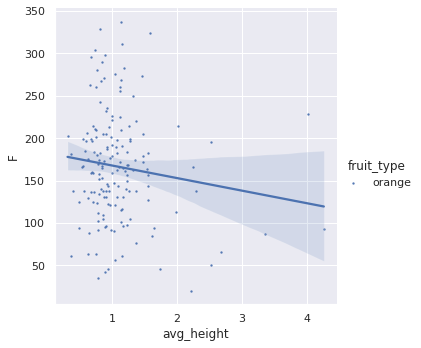

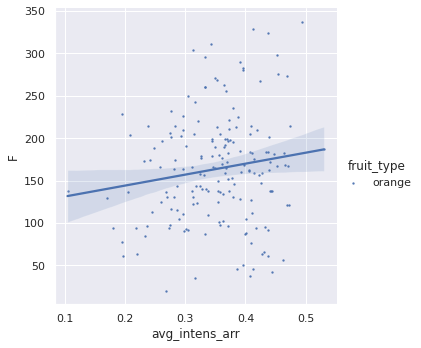

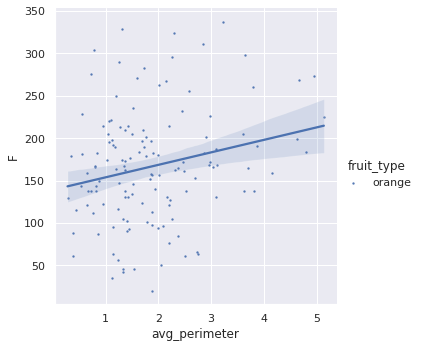

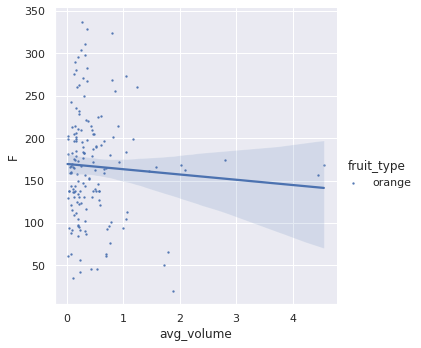

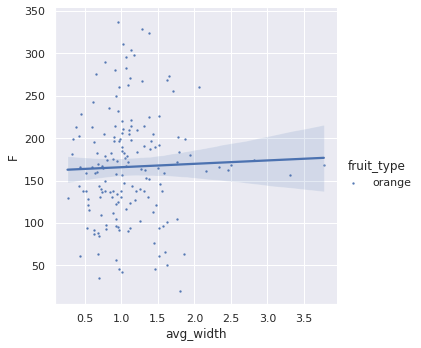

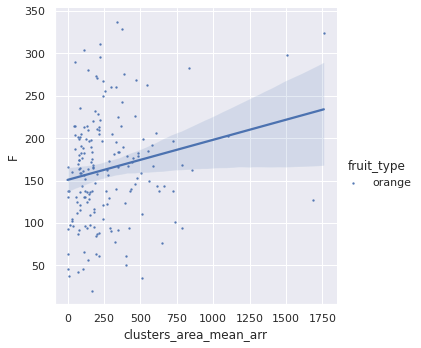

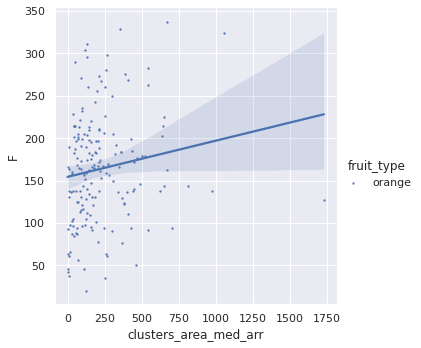

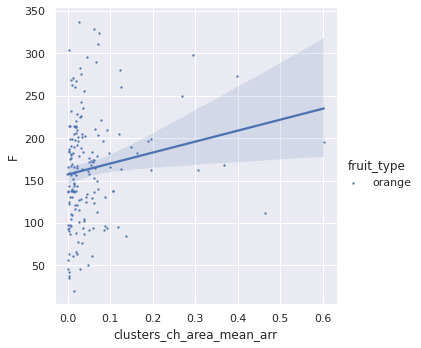

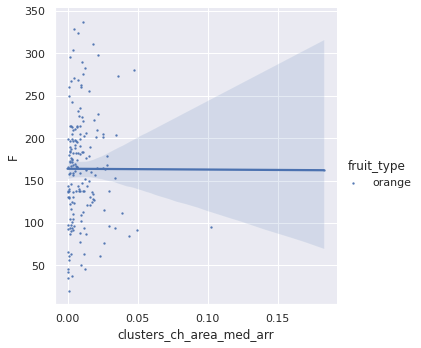

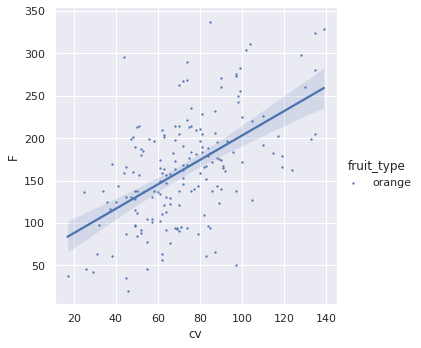

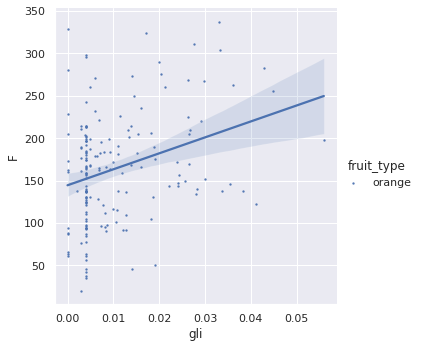

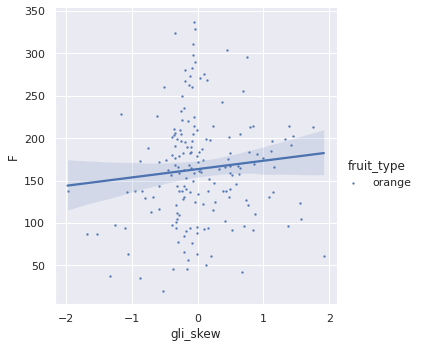

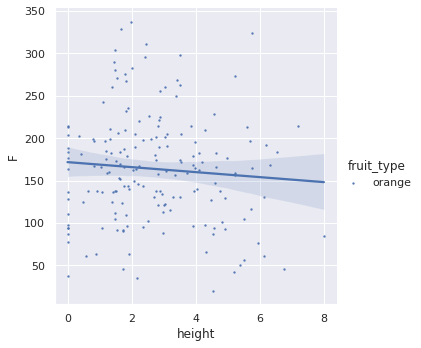

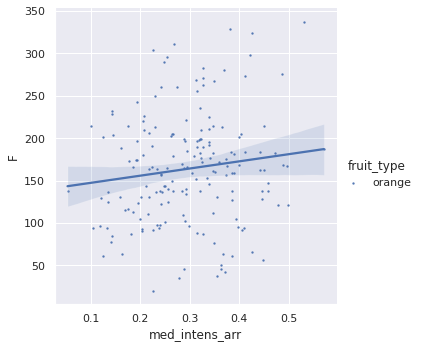

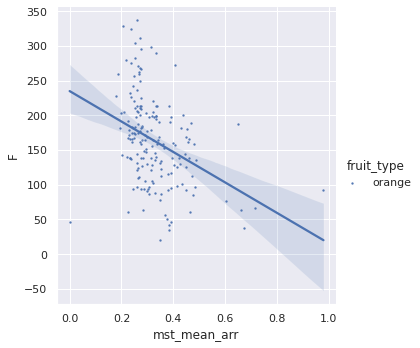

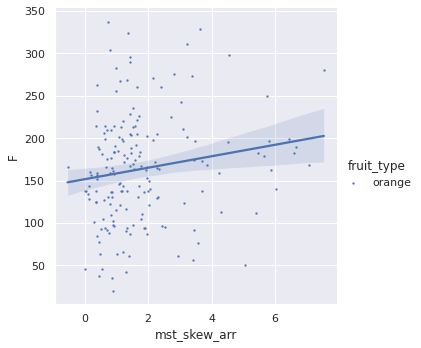

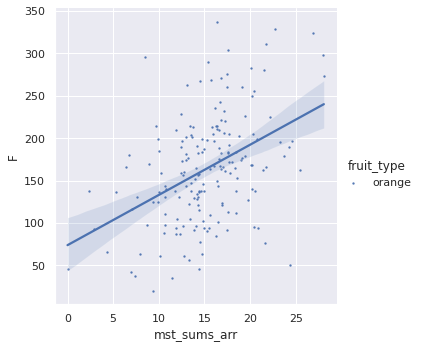

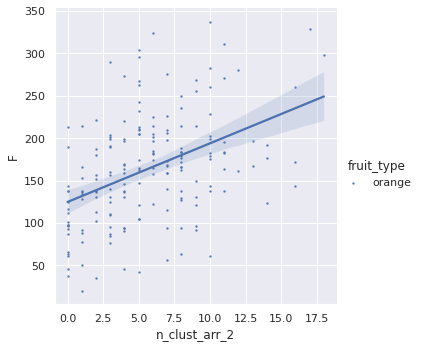

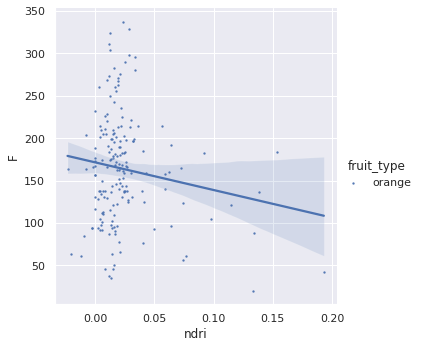

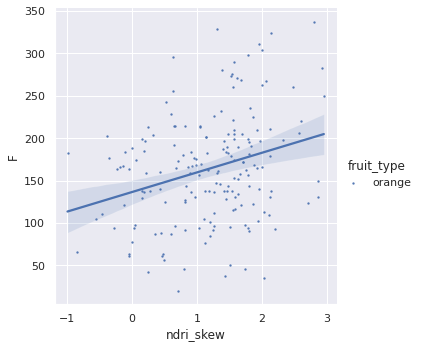

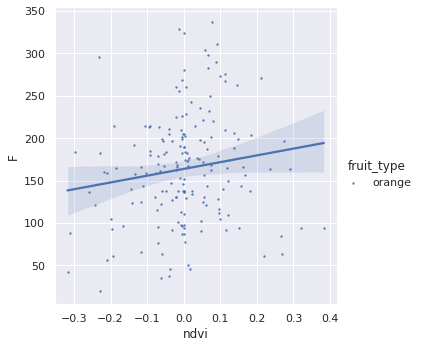

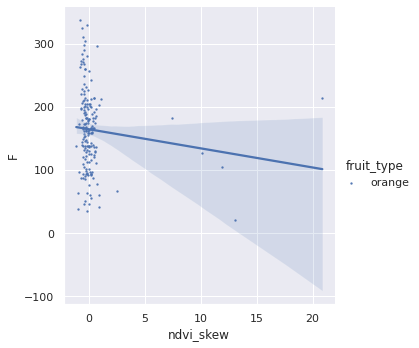

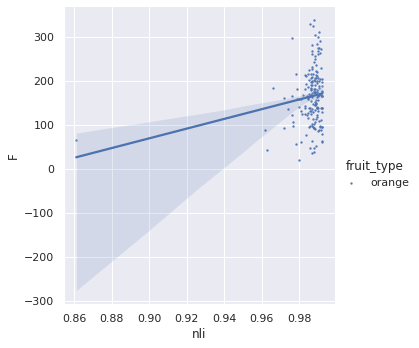

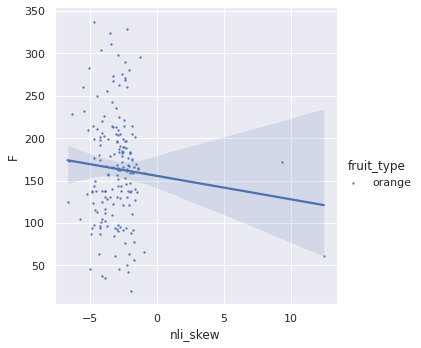

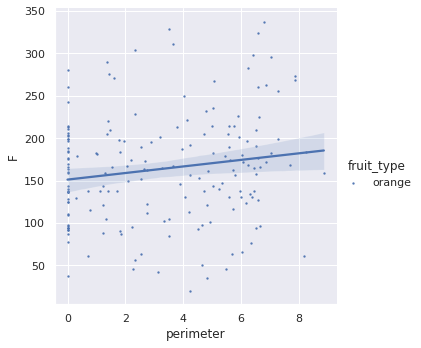

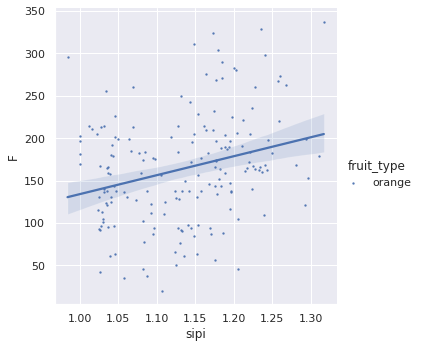

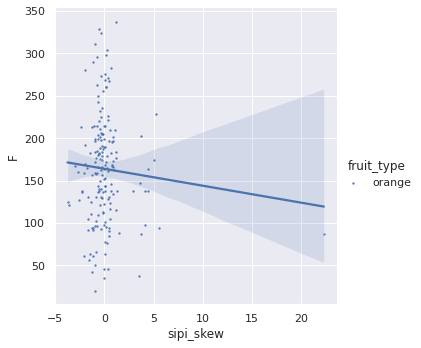

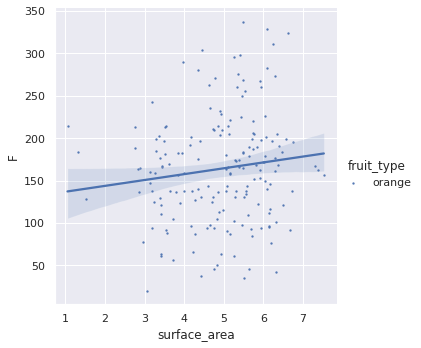

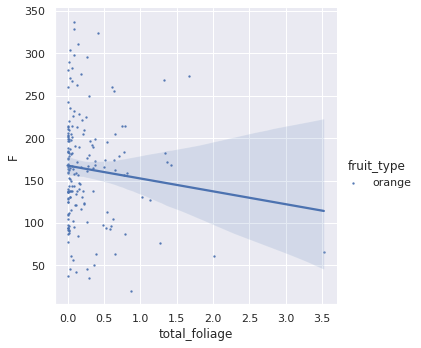

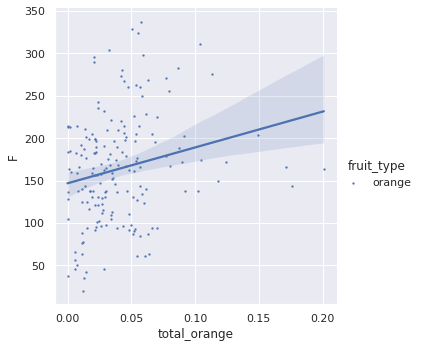

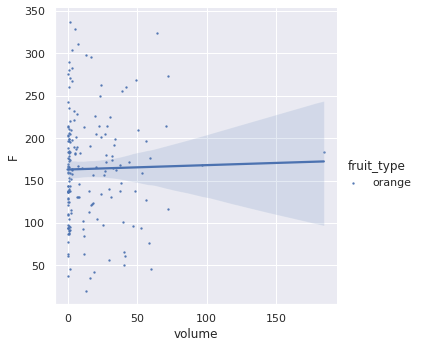

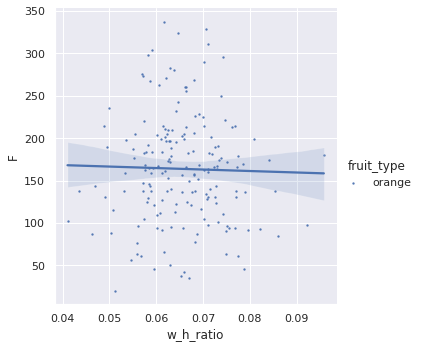

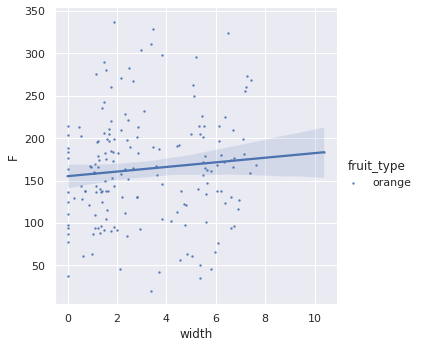

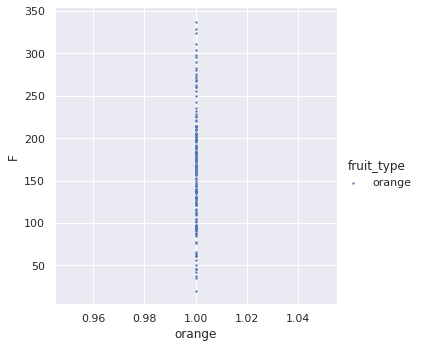

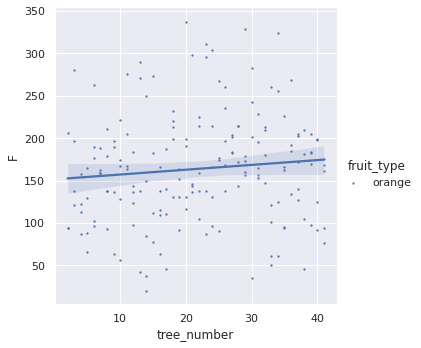

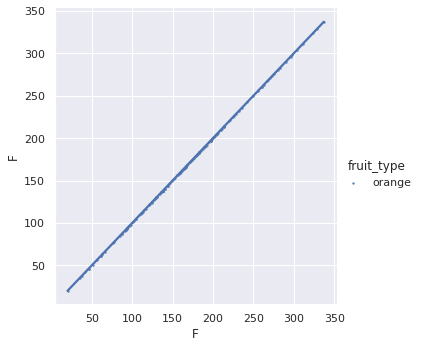

In [165]:
sns.set(font_scale=1)
for col in numer_cols:
    sns.lmplot(data = clean_set,x = col,y="F",hue= "fruit_type", scatter_kws={'s':2})
    plt.show()
clean_set.drop("fruit_type",axis = 1,inplace = True)

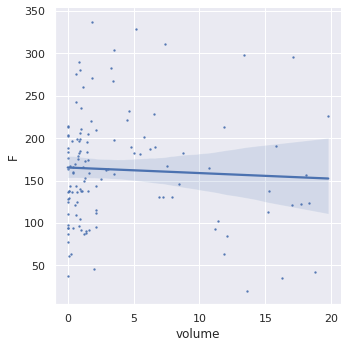

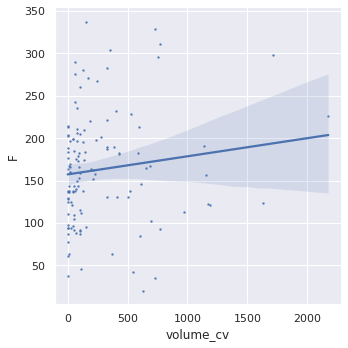

In [166]:
col = "volume"
clean_df_temp = clean_set.copy(True)
clean_df_temp = clean_df_temp[clean_df_temp[col]<20]
clean_df_temp[f"{col}_cv"] = clean_df_temp[col]*clean_df_temp["cv"]
sns.lmplot(data = clean_df_temp,x = col,y="F", scatter_kws={'s':2})
plt.show()
sns.lmplot(data = clean_df_temp,x = f"{col}_cv",y="F", scatter_kws={'s':2})
plt.show()

<AxesSubplot:>

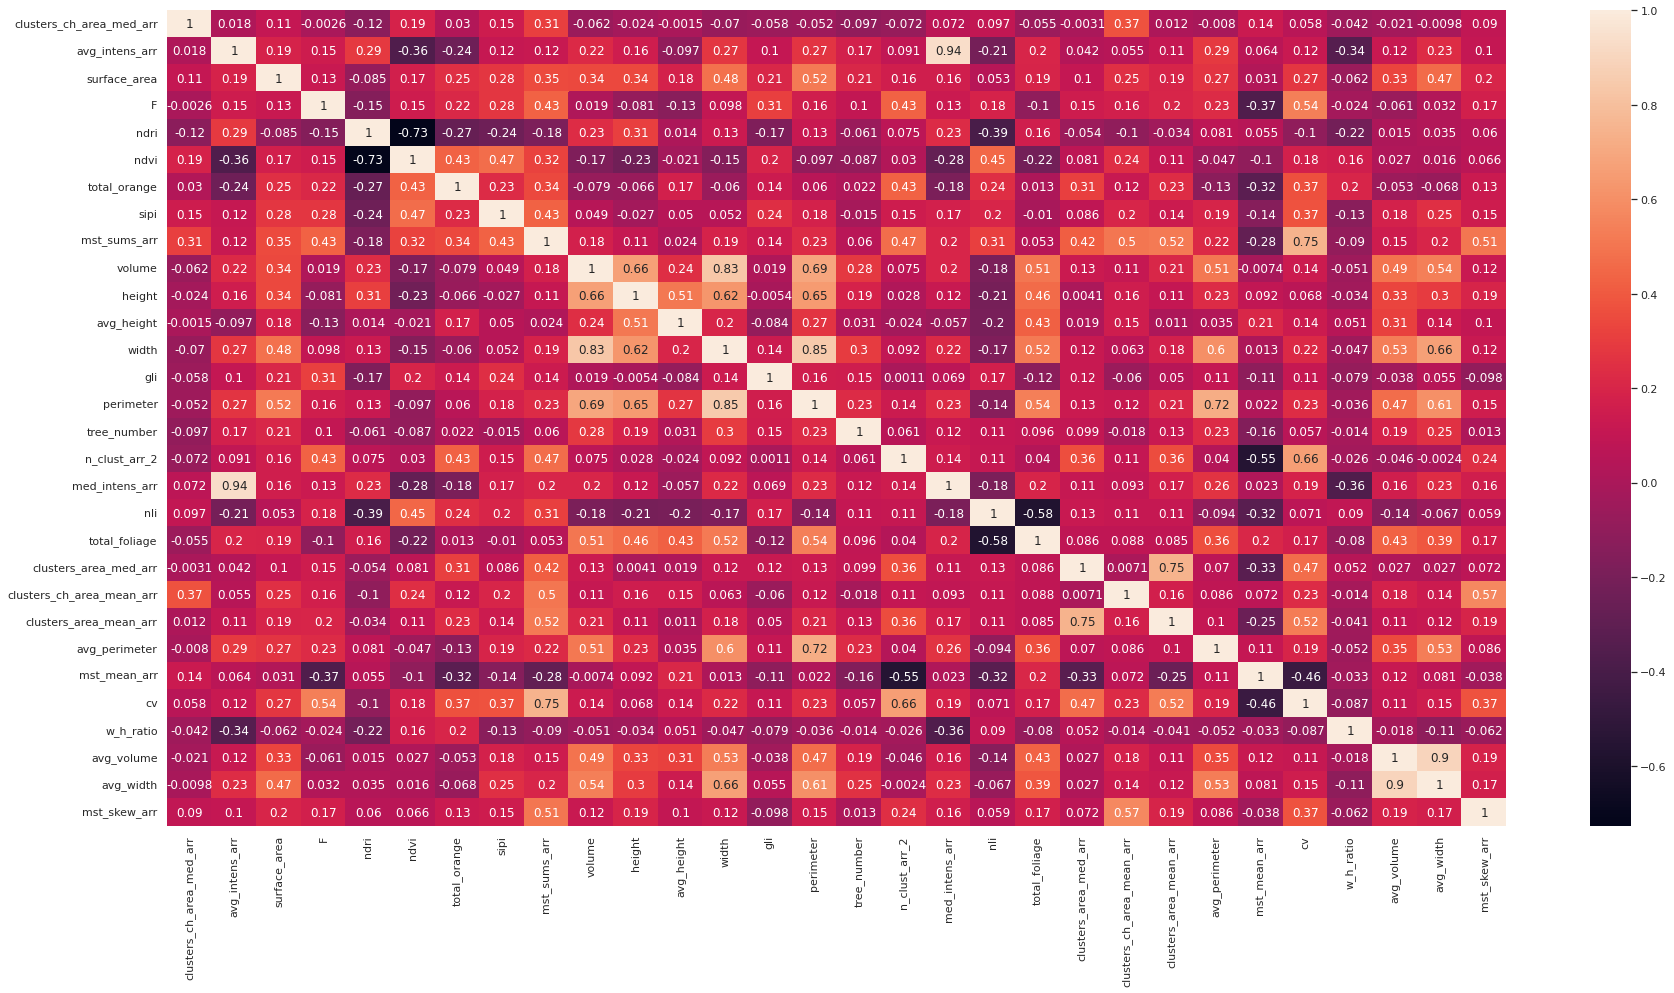

In [167]:
for_corr_plot = set([col for col in numer_cols if not col.endswith("skew")]) - {"apple",
                                                                                "mandarin","lemon","orange"}
corr_frame = clean_set[for_corr_plot].corr()
plt.figure(figsize=(30,15))
sns.heatmap(corr_frame, 
        xticklabels=corr_frame.columns,
        yticklabels=corr_frame.columns,annot = True, annot_kws={"fontsize": 12})


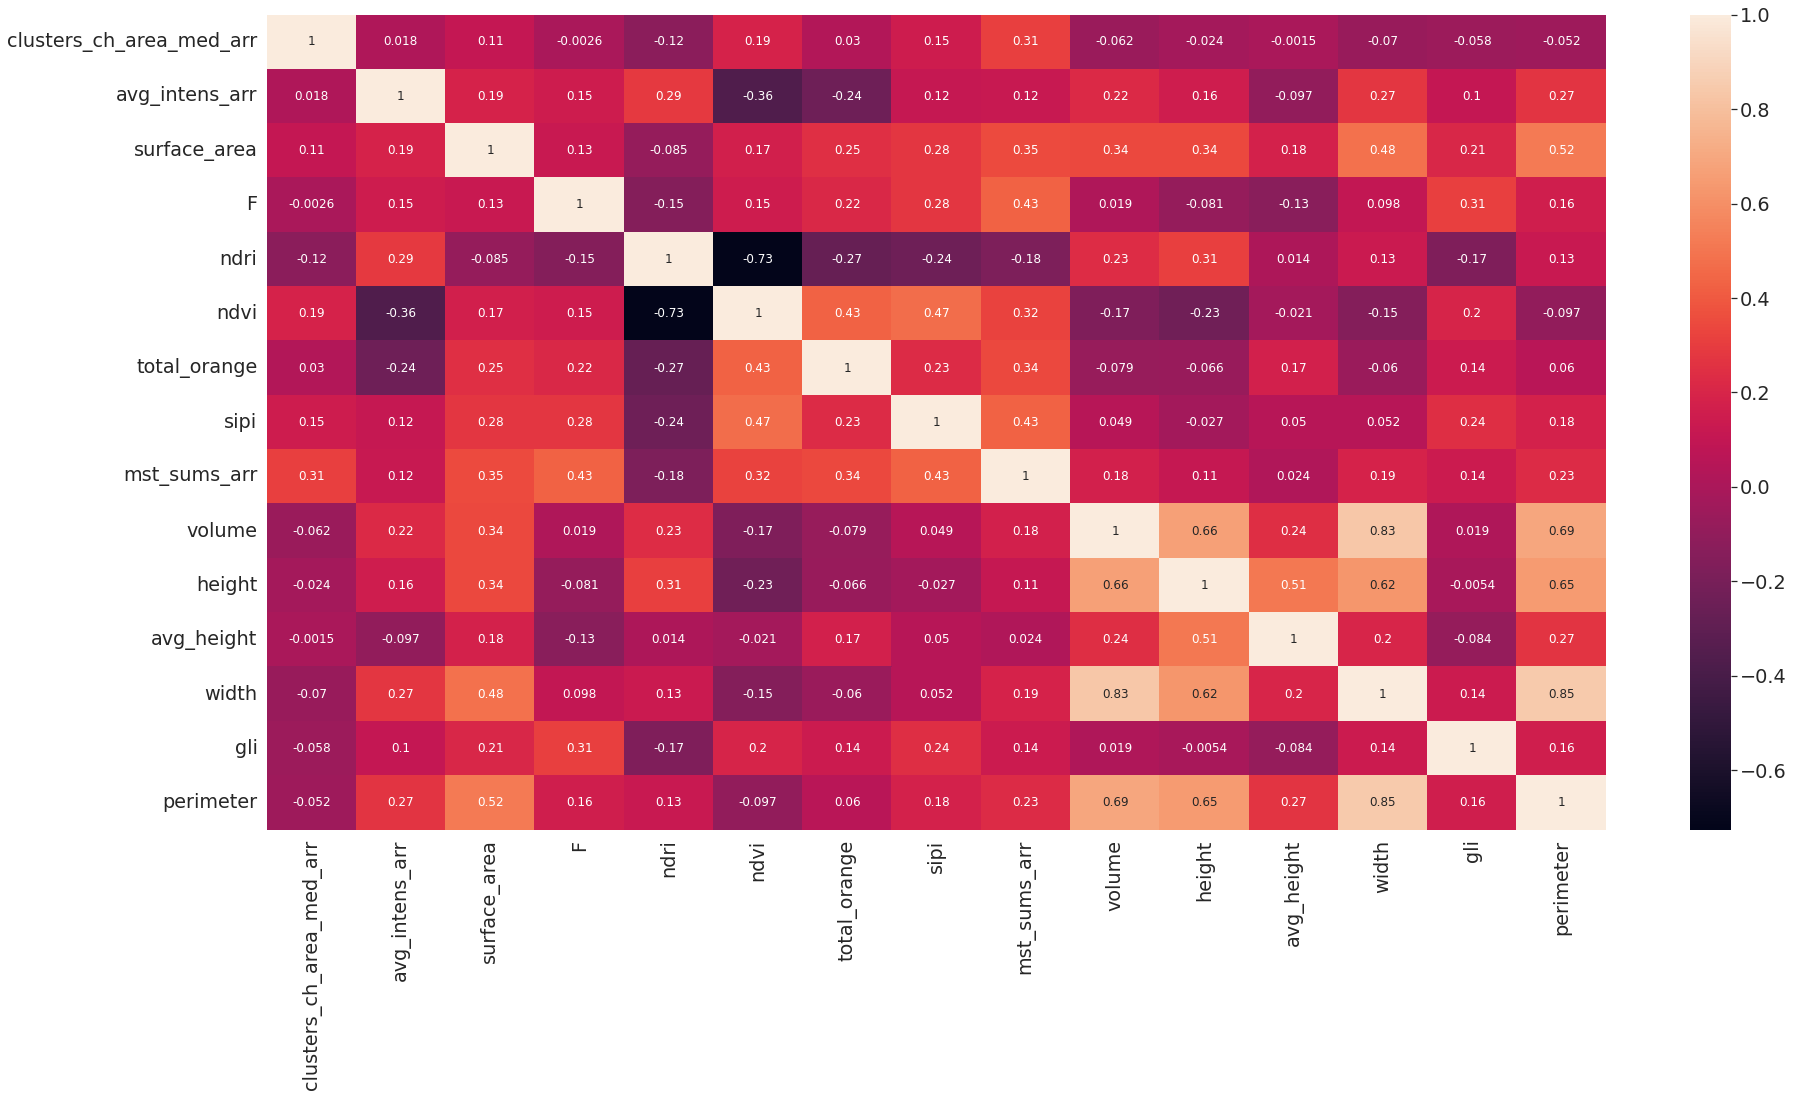

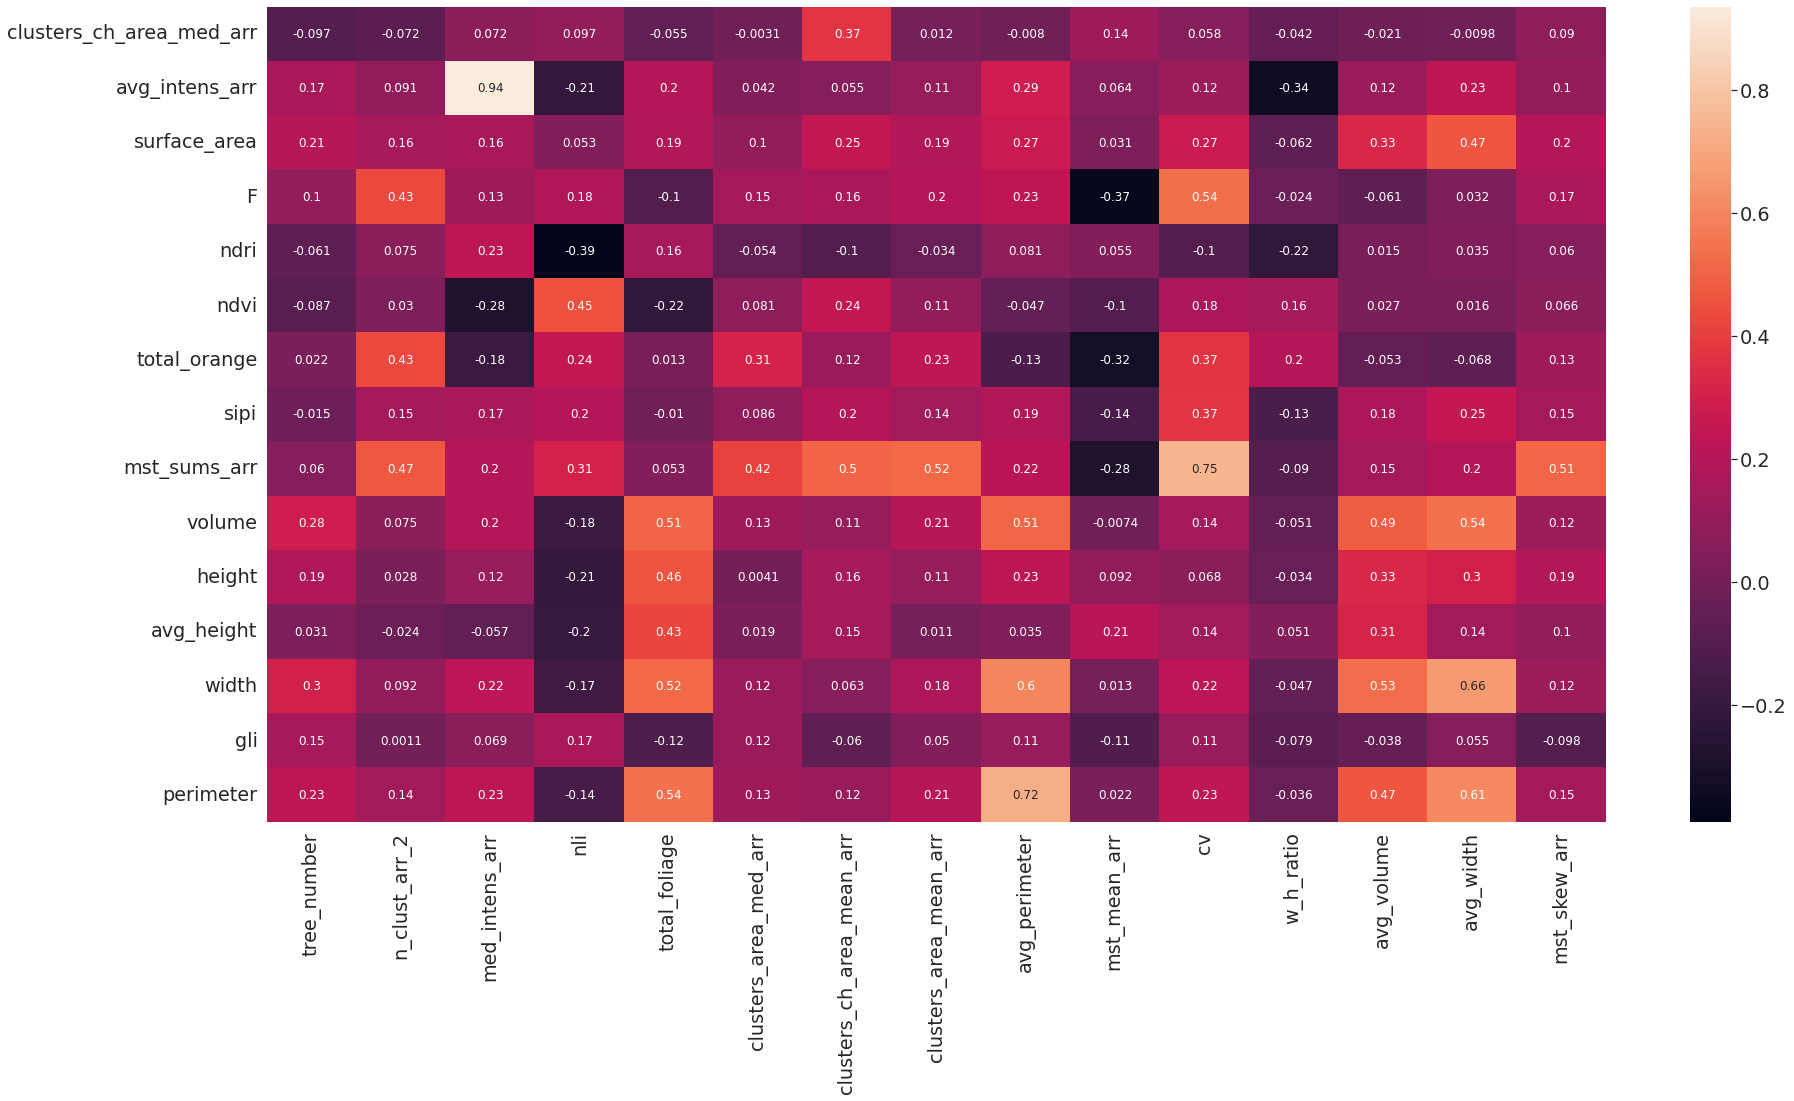

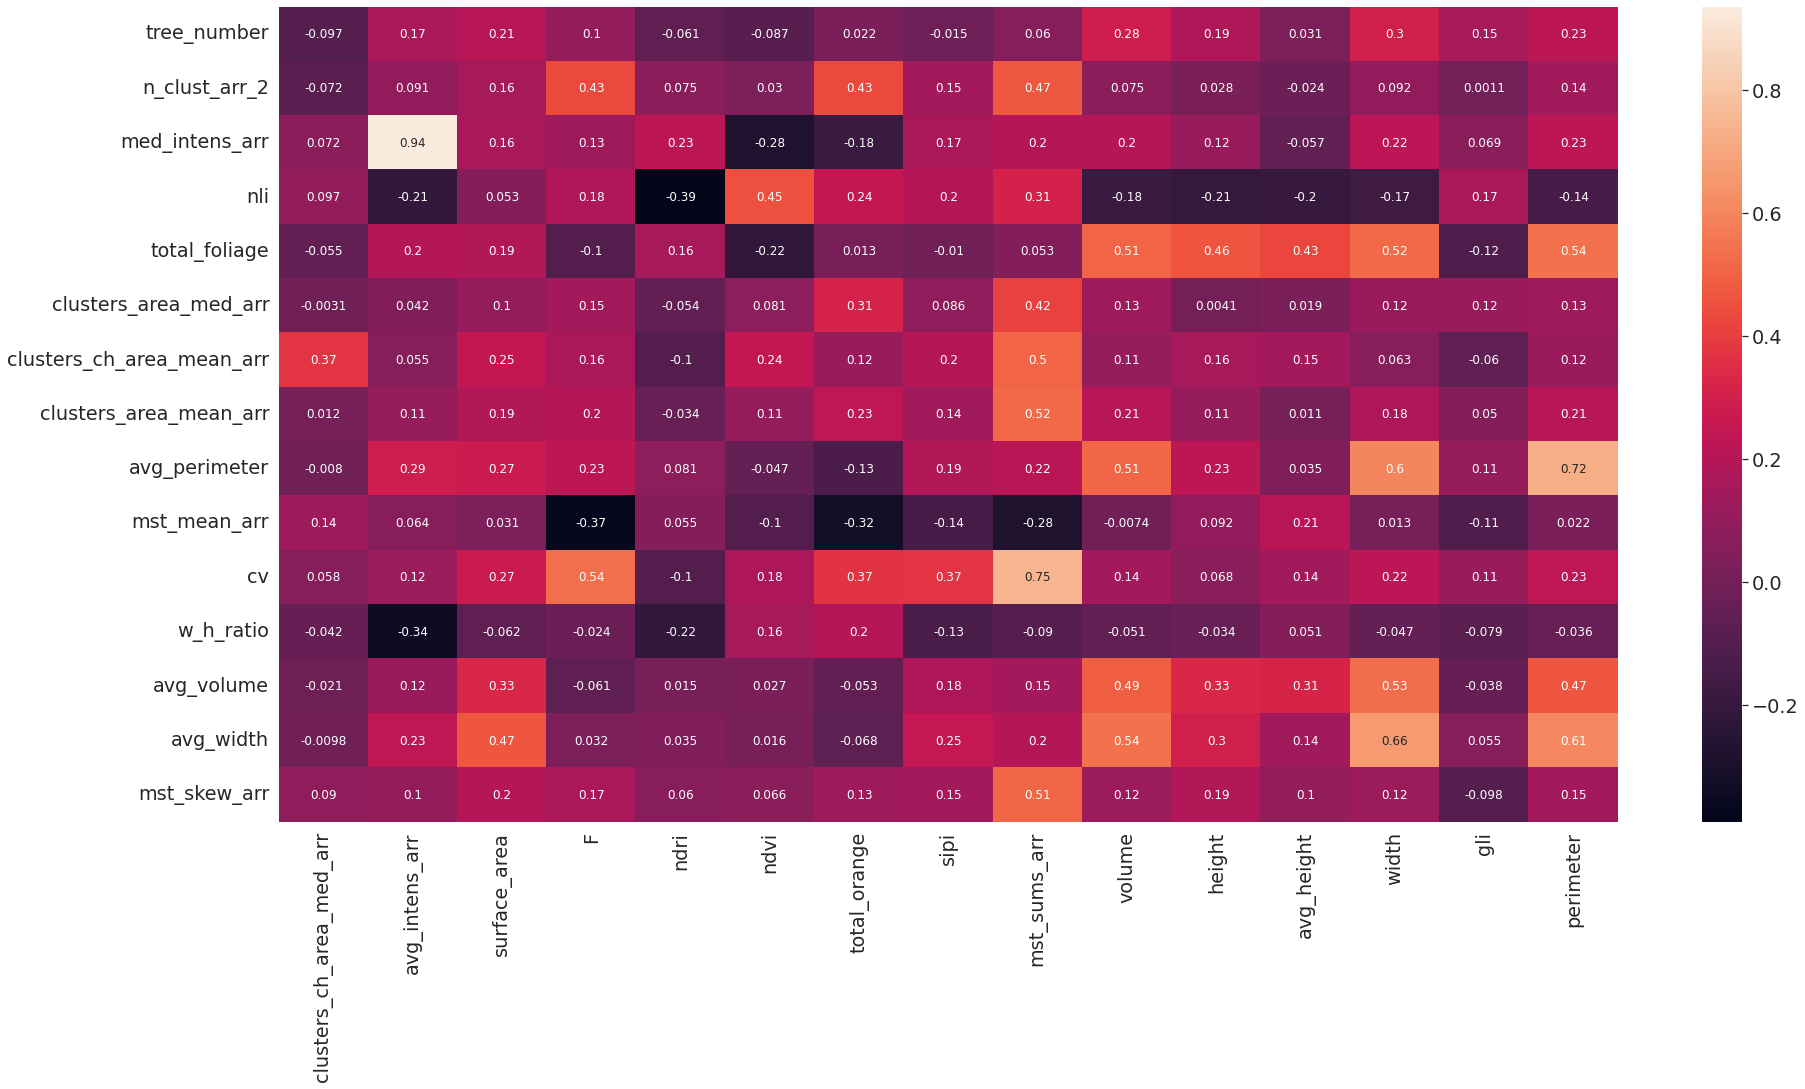

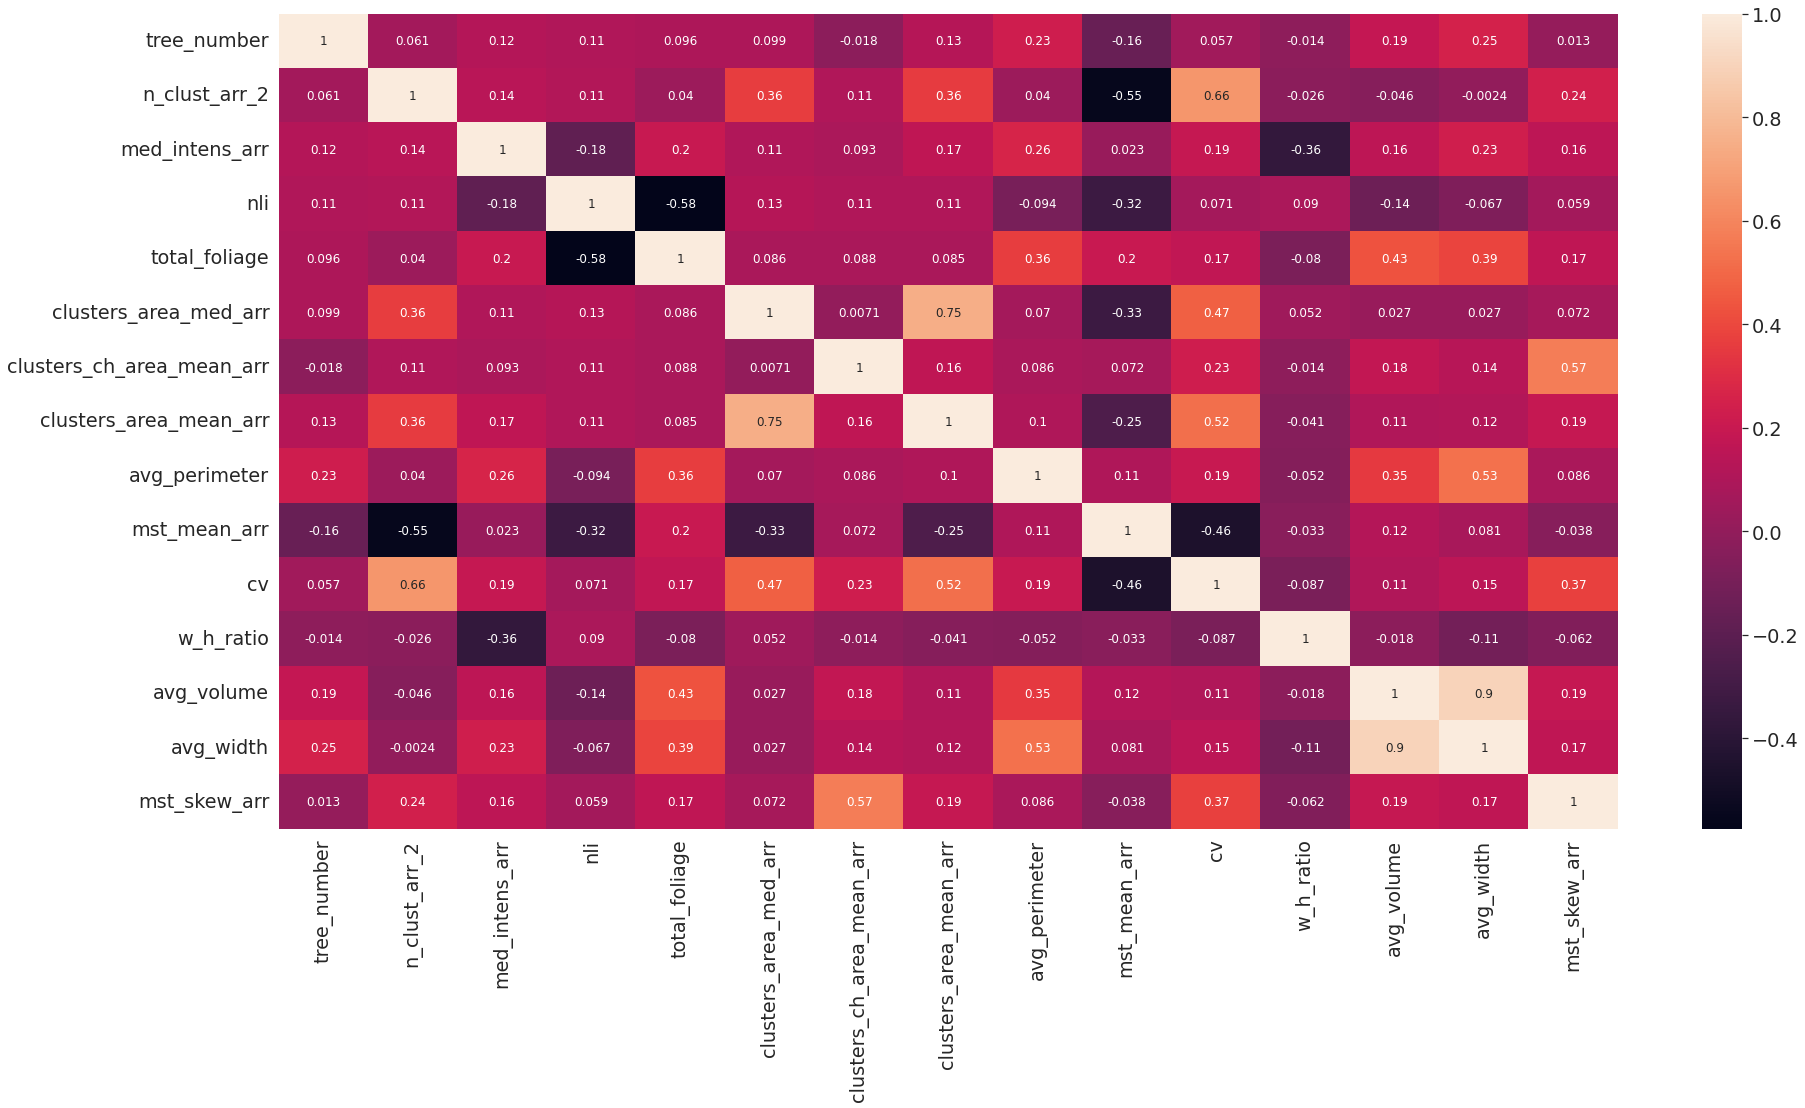

In [168]:
sns.set(font_scale=1.75)
n_cols = corr_frame.shape[0]
half_cols = int(n_cols/2)
plt.figure(figsize=(30,15))
sns.heatmap(corr_frame.iloc[:half_cols,:half_cols], 
        xticklabels=corr_frame.columns[:half_cols],
        yticklabels=corr_frame.columns[:half_cols],annot = True, annot_kws={"fontsize": 12})
plt.show()
plt.figure(figsize=(30,15))
sns.heatmap(corr_frame.iloc[:half_cols,half_cols:], 
        xticklabels=corr_frame.columns[half_cols:],
        yticklabels=corr_frame.columns[:half_cols],annot = True, annot_kws={"fontsize": 12})
plt.show()
plt.figure(figsize=(30,15))
sns.heatmap(corr_frame.iloc[half_cols:,:half_cols], 
        xticklabels=corr_frame.columns[:half_cols],
        yticklabels=corr_frame.columns[half_cols:],annot = True, annot_kws={"fontsize": 12})
plt.show()
plt.figure(figsize=(30,15))
sns.heatmap(corr_frame.iloc[half_cols:,half_cols:], 
        xticklabels=corr_frame.columns[half_cols:],
        yticklabels=corr_frame.columns[half_cols:],annot = True, annot_kws={"fontsize": 12})
plt.show()

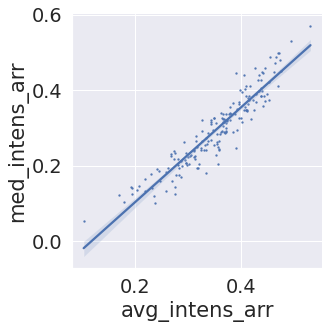

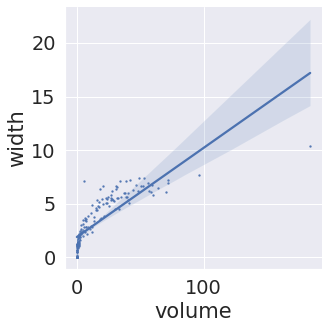

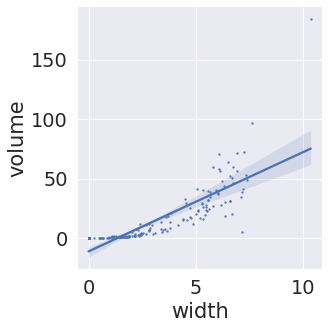

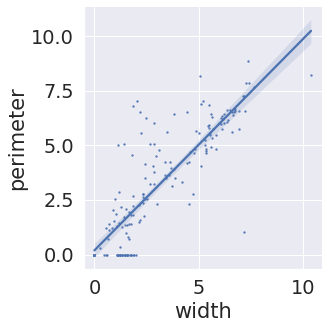

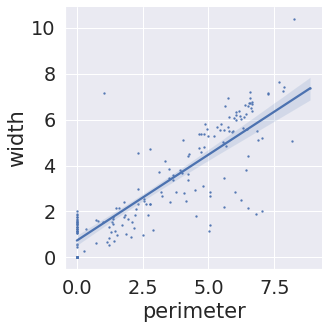

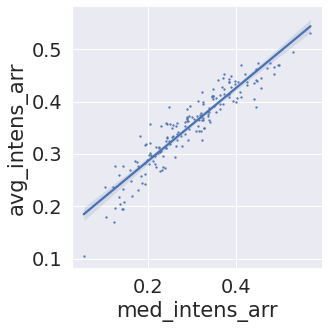

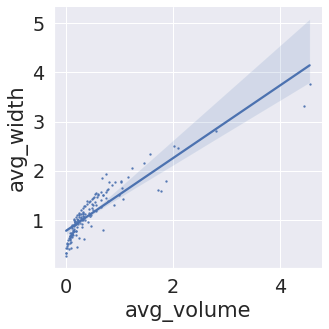

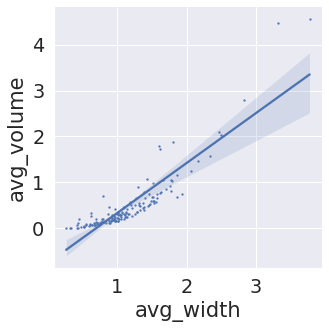

In [169]:
corr_frame_stacked = corr_frame.stack().to_frame()
bool_vec = np.all([np.abs(corr_frame_stacked[0].values) > 0.8 , np.abs(corr_frame_stacked[0].values) < 1],axis = 0)
for i, row in corr_frame_stacked[bool_vec].iterrows():
    var1, var2 = row.name
    sns.lmplot(data = clean_set,x = var1,y=var2, scatter_kws={'s':2})
    plt.show()

### PCA

In [170]:
rows = clean_set["name"].apply(lambda x: x.split("_")[0])
X_tr_lr = clean_set.copy()
y = X_tr_lr['F']
X_tr_lr.drop("F",axis = 1,inplace = True)
X_tr_lr.drop(["block_name","side","tree_number", "name"],axis = 1,inplace = True)
X_tr_lr['cv^2'] = X_tr_lr["cv"]**2
X_tr_lr['1/mst_mean_arr'] = 1/(X_tr_lr["mst_mean_arr"]+1)
X_tr_lr['mst_sums_arr^2'] = X_tr_lr["mst_sums_arr"]**2
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
X_tr_lr_selected = selector.fit_transform(X_tr_lr)
X_tr_lr = pd.DataFrame(X_tr_lr_selected,columns = X_tr_lr.columns[selector.get_support()])

In [171]:
rows.reset_index(inplace = True, drop = True)
X_tr_lr.reset_index(inplace = True, drop = True)
y.reset_index(inplace = True, drop = True)
X_tr_lr.fillna(0, inplace = True)

In [172]:
n_comp = None
pca = PCA(n_comp)
X_tr_lr_sc = StandardScaler().fit_transform(X_tr_lr)
x_pcaed = pca.fit_transform(X_tr_lr_sc, y)
x_pcaed = pd.DataFrame(x_pcaed,columns = [f"PC_{i+1}" for i in range(n_comp if n_comp != None else X_tr_lr.shape[1])])

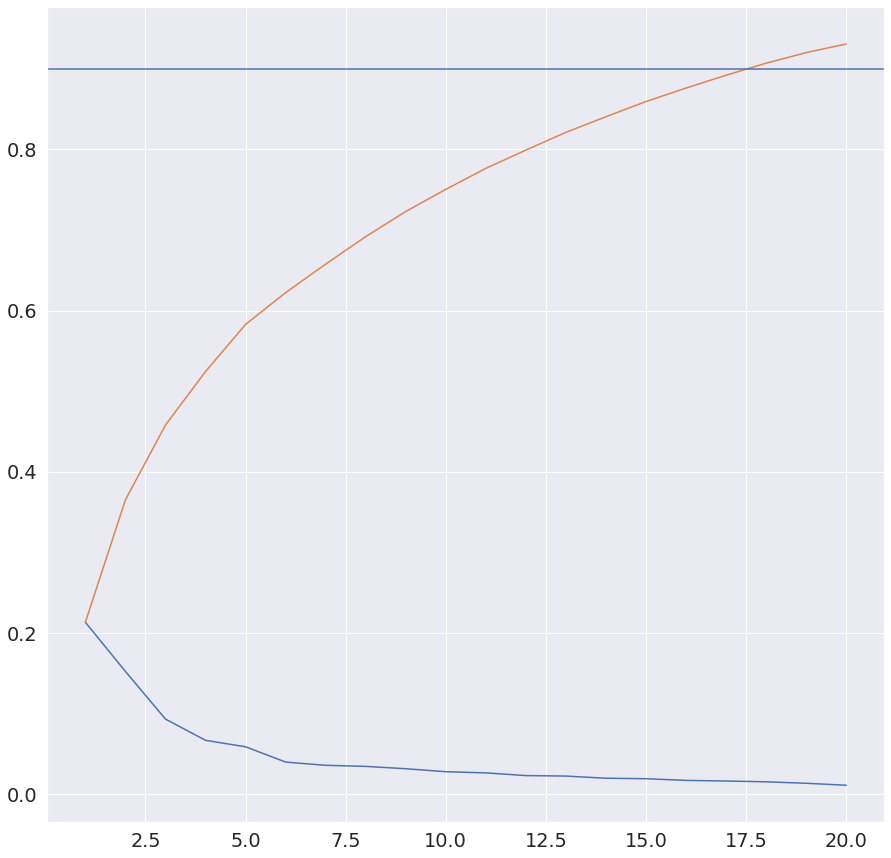

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
gli_skew,0.033075,0.076448,0.304526,0.092008,0.051250,0.414164,0.106702,0.292873,0.085061,0.007391,...,0.090207,0.003033,0.128352,0.126229,0.050731,0.010527,0.038846,0.028243,0.021761,0.006927
ndvi,0.025944,0.260085,0.301416,0.039804,0.051318,0.005867,0.051413,0.186428,0.216576,0.143416,...,0.416962,0.453831,0.202974,0.172552,0.073566,0.048016,0.065367,0.004925,0.000061,0.013954
ndri,0.016683,0.219834,0.288113,0.058790,0.005444,0.037662,0.152317,0.188568,0.226047,0.090151,...,0.148337,0.420096,0.294336,0.096331,0.029731,0.041904,0.054704,0.031090,0.029686,0.006207
n_clust_arr_2,0.163666,0.182530,0.255422,0.095382,0.002339,0.073106,0.164905,0.073683,0.160664,0.017180,...,0.056770,0.001479,0.015735,0.029879,0.035851,0.049687,0.019274,0.054932,0.006095,0.011260
ndri_skew,0.138312,0.040822,0.249528,0.058940,0.317549,0.207710,0.024850,0.019013,0.296274,0.046147,...,0.062285,0.040998,0.035238,0.169689,0.033201,0.055652,0.037963,0.006663,0.002478,0.005672
1/mst_mean_arr,0.074261,0.226970,0.247317,0.277215,0.174287,0.073378,0.267675,0.115186,0.054494,0.046470,...,0.006318,0.075018,0.044264,0.012632,0.020795,0.006498,0.029929,0.214776,0.407385,0.538017
mst_mean_arr,0.072672,0.235117,0.240739,0.253124,0.180979,0.043084,0.286885,0.126301,0.099391,0.046126,...,0.040771,0.054584,0.039185,0.063248,0.012697,0.032895,0.038114,0.179691,0.425223,0.517562
ndvi_skew,0.009221,0.144339,0.228478,0.103370,0.162383,0.057802,0.060465,0.195783,0.108998,0.167415,...,0.014035,0.073428,0.076274,0.018123,0.027496,0.017778,0.031325,0.021157,0.012196,0.000240
surface_area,0.226212,0.011119,0.227969,0.006609,0.106250,0.023609,0.027106,0.004566,0.227174,0.166426,...,0.025255,0.021372,0.120583,0.080276,0.132544,0.049312,0.048279,0.008828,0.003078,0.003121
nli_skew,0.055607,0.078450,0.222562,0.046993,0.108740,0.087035,0.119784,0.559058,0.178581,0.191882,...,0.064343,0.039287,0.116192,0.181213,0.066110,0.009027,0.017576,0.019295,0.006061,0.004134


In [173]:
max_comp = 20
plt.figure(figsize=(15,15))
plt.plot(range(1,max_comp+1),pca.explained_variance_ratio_[:max_comp])
plt.plot(range(1,max_comp+1),np.cumsum(pca.explained_variance_ratio_[:max_comp]))
plt.axhline(0.9)
plt.show()
pd.DataFrame(np.abs(pca.components_.T), index = X_tr_lr.columns).sort_values(2,ascending = False)

In [174]:
# X_tr_lr[x_pcaed.columns] = x_pcaed

### modeling

In [175]:
def mape(y_true,y_pred,trees):
    df = pd.DataFrame({"F":y_true,"prediction_F":y_pred,"trees":trees})
    agg_table = pd.pivot_table(df,index = "trees",values = ["prediction_F","F"],aggfunc = np.mean)
    return np.mean(np.abs(agg_table["F"]- agg_table["prediction_F"]) / agg_table["F"])

def mape_scoring(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)/y_true)

def naive_prediction(data,frames = True):
    df = data.copy(True)
    if frames:
        df = df[df["frame"] == 1] 
    fruit_avg = {col: df["F"][df[col] == 1].mean()
                 for col in ["orange","lemon","mandarin","apple"] if col in df.columns}
    print(fruit_avg)
    predictions = data[fruit_avg.keys()] * fruit_avg
    return predictions.max(axis =1)

def naive_score(data,frames = True):
    predictions = naive_prediction(data,frames)
    return mape_scoring(data["F"],predictions)
print(naive_score(clean_set,frames = False))

{'orange': 163.72316384180792}
0.456169428750176


In [176]:
class model_hybrid_selector(BaseEstimator):
    
    def __init__(self, base_estimator=LinearRegression(), params = {},
                 scoring="neg_mean_absolute_percentage_error", statisticly = False):
        print(params)
        if len(params)>0:
            self.model = base_estimator(**params)
        else:
            self.model = base_estimator
        self.cols = []
        self.scoring= scoring
        self.stratify = None
        self.statisticly = statisticly

    def get_score(self,X_tr,y_tr,cols,cv=8, n_jobs=-1,random_state = None):
        if not isinstance(self.stratify, type(None)):
            cv = StratifiedKFold(cv, shuffle= True,random_state=random_state)
        score = cross_validate(self.model, X_tr[cols] , y=y_tr,cv=cv, n_jobs=n_jobs, 
                                                        scoring=self.scoring)
        test_scores = score["test_score"]
        return np.mean(test_scores * (-1)), np.std(test_scores)

    def get_candidate(self,results_dict, results_stds, cur_score):
        sort_by = "z_score" if self.statisticly else "new_result"
        new_results = list(results_dict.values())
        z_score = (np.array(new_results) - cur_score) / np.array(results_stds)
        df = pd.DataFrame({"feature": list(results_dict.keys()),
                           "new_result": list(results_dict.values()),
                           "z_score": z_score}).sort_values(sort_by)
        return df.iloc[0] if self.statisticly else df.iloc[0]

    def print_results(self,canidate,cur_score,cols,added = True):
        change = 0
        status = "added" if added else "removed"
        new_score = canidate["new_result"]
        if np.isnan(new_score):
            return cur_score,change,cols
        if new_score < cur_score:
            feature = canidate["feature"]
            if added:
                cols.append(feature)
            elif feature in cols:
                cols.remove(feature)
            change = 1
            print(f"{status} {feature}, new_score: {new_score}")
        else:
            print(f"no feature could be {status}, new_score: {new_score}")
        return new_score,change,cols   
    
    def step(self,X_tr,y_tr,use_alwyas,cols,cur_score, forward = True):
        results_dict, results_stds, change = {}, [], 0
        canidate_cols = set(X_tr.columns) - set(use_alwyas) - set(cols) if forward else set(cols) - set(use_alwyas)
        if len(canidate_cols) == 0:
            return cols,change,cur_score 
        random_state = np.random.randint(0,1000,1)[0]
        assured_cols = cols + use_alwyas
        for col in tqdm(canidate_cols):
            train_cols =  assured_cols + [col] if forward else set(assured_cols) - {col}
            results_dict[col], cur_std = self.get_score(X_tr, y_tr, train_cols, random_state=random_state)
            results_stds.append(cur_std)
        candidate = self.get_candidate(results_dict, results_stds, cur_score)
        new_score,change,cols = self.print_results(candidate,cur_score,cols,added = forward)
        return cols,change, min(new_score,cur_score)

    def hybrid_stepwise_selection(self,X_tr,y_tr,num_stuck = 3,cols = [], use_alwyas = []):
        no_change, cur_score = 0, np.inf
        print(cur_score)
        while no_change < num_stuck:
            cols,added_result,cur_score = self.step(X_tr,y_tr,use_alwyas,cols,cur_score)
            cols,removed_result,cur_score = self.step(X_tr,y_tr,use_alwyas,cols,cur_score, forward = False)
            if added_result or removed_result:
                no_change = 0
            else:
                no_change += 1
            print(f"score: {cur_score},cols: {cols}")
        return cols + use_alwyas,cur_score
    
    def fit(self,X_tr,y_tr,num_stuck = 3,cols = [], use_alwyas = [], stratify = None):
        self.stratify = stratify
        self.cols,cur_score = self.hybrid_stepwise_selection(X_tr,y_tr,num_stuck,cols,use_alwyas)
        self.model.fit(X_tr[self.cols],y_tr)
        return cur_score

    def fitplusplus(self,X_tr,y_tr,num_stuck = 3, stratify = None,n_iter = 15):
        self.stratify = stratify
        all_cols_list = list(X_tr.columns)
        n_cols = len(all_cols_list)
        cols_arr = {}
        for i in range(1,n_iter+1):
            if i == 1:
                cols = []
            elif i == 2:
                cols = all_cols_list.copy()
            else:
                size = np.random.randint(1,n_cols-1)
                cols = np.random.choice(all_cols_list.copy(),size = size,replace = False).tolist()
            self.fit(X_tr,y_tr,num_stuck = num_stuck,cols = cols,stratify = stratify)
            cols_arr[i] = {"cols": self.cols, "score": self.get_score(X_tr,y_tr,self.cols, n_jobs=-1)}
            print(self.cols)
            print(i)
        cols_arr_sorted = {k: v for k, v in sorted(cols_arr.items(), key=lambda item: item[1]["score"])}
        best_iteration = cols_arr[list(cols_arr_sorted.keys())[0]]
        self.cols = best_iteration["cols"]
        return best_iteration["score"]
        
    def predict(self,X_pred):
        return self.model.predict(X_pred[self.cols])
    
    def fit_predict(self,X_tr,y_tr,num_stuck = 3,cols = [], use_alwyas = [], stratify = None):
        self.fit(X_tr,y_tr,num_stuck,cols,use_alwyas,stratify)
        return self.predict(X_tr)
    
    def iterative_fitting(self,X_tr,y_tr,num_stuck = 3,cols = [], use_alwyas = [], stratify = None,n_iter = 15,
                         sampling = 0.8):
        self.stratify = stratify
        cols_arr = {}
        for i in range(1,n_iter+1):
            self.fit(X_tr,y_tr,num_stuck = num_stuck,cols = cols,stratify = stratify)
            cols = self.cols
            if i > 1:
                cols_arr_sorted = {k: v for k, v in sorted(cols_arr.items(), key=lambda item: item[1]["score"])}
                best_iteration = cols_arr[list(cols_arr_sorted.keys())[0]]
                cols = best_iteration["cols"]
            cols = np.random.choice(np.array(cols),replace = False,size=int(sampling*len(cols))).tolist()
            cols_arr[i] = {"cols": self.cols, "score": self.get_score(X_tr,y_tr,self.cols, n_jobs=-1)}
            print(self.cols)
            print(i)
        cols_arr_sorted = {k: v for k, v in sorted(cols_arr.items(), key=lambda item: item[1]["score"])}
        best_iteration = cols_arr[list(cols_arr_sorted.keys())[0]]
        self.cols = best_iteration["cols"]
        return best_iteration["score"]


### baseline

In [177]:
# TODO add cols
sc = scalers["Power"]

def cross_validate_with_mean(model = None, X = None,y = None,cv = 16, groups = None):
    results = []
    tree_res = []
    X = X.to_numpy()
    if not isinstance(y, type(np.array([]))):
        y = y.to_numpy()
    if not isinstance(groups,type(None)):
        cv = groups.nunique()
        kf = GroupKFold(n_splits=cv)
        iterable_kf = kf.split(X,y,groups)
    else:
        kf = KFold(n_splits=cv, random_state=43, shuffle=True)
        iterable_kf = kf.split(X)
    for train_index, test_index in iterable_kf:
        x_train, x_test, y_train, y_test = X[train_index] , X[test_index], y[train_index] , y[test_index]
        #x_train, x_test, y_train, y_test = X[test_index] , X[train_index], y[test_index] , y[train_index]
        if isinstance(model,type(None)):
            y_pred = np.array([np.mean(y_train)]*len(y_test))
        else:
            model.fit(x_train,y_train)
            y_pred = model.predict(x_test)
        y_true_sum = y_test.sum()
        results.append(abs(y_pred.sum() - y_true_sum)/(y_true_sum))
        tree_res.append(np.mean(abs(y_pred-y_test)/(y_test)))
        test_group = ""
        if not isinstance(groups,type(None)):
            test_group = f"({groups[test_index[0]]})"
        y_pred_sum = y_pred.sum()
        acc = np.abs(y_true_sum-y_pred_sum)/y_true_sum
        print(F"true: {y_true_sum},    pred: {y_pred_sum}. ({acc*100 :.2f} %) {test_group}" )
    print(np.mean(tree_res))
    return np.mean(results), np.std(results)
print(cross_validate_with_mean(None,X_tr_lr,y))

print(cross_validate_with_mean(None,X_tr_lr,y,groups = rows))

true: 1783.0,    pred: 1977.8909090909087. (10.93 %) 
true: 1842.0,    pred: 1798.234939759036. (2.38 %) 
true: 1813.0,    pred: 1800.1566265060244. (0.71 %) 
true: 1879.0,    pred: 1795.7831325301208. (4.43 %) 
true: 1455.0,    pred: 1823.8795180722889. (25.35 %) 
true: 1938.0,    pred: 1791.8734939759036. (7.54 %) 
true: 2053.0,    pred: 1784.253012048193. (13.09 %) 
true: 1512.0,    pred: 1820.1024096385543. (20.38 %) 
true: 1795.0,    pred: 1801.3493975903611. (0.35 %) 
true: 2018.0,    pred: 1786.5722891566263. (11.47 %) 
true: 1908.0,    pred: 1793.8614457831327. (5.98 %) 
true: 1581.0,    pred: 1815.5301204819277. (14.83 %) 
true: 1679.0,    pred: 1809.0361445783133. (7.74 %) 
true: 2009.0,    pred: 1787.168674698795. (11.04 %) 
true: 1575.0,    pred: 1815.9277108433737. (15.30 %) 
true: 2139.0,    pred: 1778.5542168674701. (16.85 %) 
0.4592958734499244
(0.10523563492744042, 0.0683215499930726)
true: 2797.0,    pred: 3335.286624203821. (19.25 %) (R9)
true: 2882.0,    pred: 3324.

### fit linear

In [178]:
mhs = model_hybrid_selector()
mhs.iterative_fitting(X_tr_lr,y,num_stuck = 3,cols = [],use_alwyas = [])
# mhs.fit(X_tr_lr,y,num_stuck = 3,cols = [],use_alwyas = [])


{}
inf


100%|██████████| 36/36 [00:02<00:00, 17.58it/s]


added cv, new_score: 0.3740220607653048


100%|██████████| 1/1 [00:00<00:00, 104.69it/s]


score: 0.3740220607653048,cols: ['cv']


...

100%|██████████| 27/27 [00:00<00:00, 59.45it/s]


no feature could be added, new_score: 0.32471049304906474


100%|██████████| 9/9 [00:00<00:00, 59.75it/s]

no feature could be removed, new_score: 0.32621273610460916
score: 0.3243366116865505,cols: ['n_clust_arr_2', 'perimeter', 'clusters_ch_area_mean_arr', 'gli', 'clusters_area_med_arr', 'total_foliage', 'height', 'cv', 'sipi_skew']
['n_clust_arr_2', 'perimeter', 'clusters_ch_area_mean_arr', 'gli', 'clusters_area_med_arr', 'total_foliage', 'height', 'cv', 'sipi_skew']
15


(0.32433661168651395, 0.05350370404339388)

In [179]:
mhs.cols

['cv',
 'gli',
 'total_foliage',
 'clusters_area_med_arr',
 'perimeter',
 'height',
 'n_clust_arr_2',
 'sipi_skew',
 'clusters_ch_area_mean_arr']

In [180]:
print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhs.cols],y))

print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhs.cols],y,groups = rows))

true: 1783.0,    pred: 1917.0410309549254. (7.52 %) 
true: 1842.0,    pred: 1850.9027873038995. (0.48 %) 
true: 1813.0,    pred: 1847.108523173046. (1.88 %) 
true: 1879.0,    pred: 2035.4368084023886. (8.33 %) 
true: 1455.0,    pred: 1766.281407161029. (21.39 %) 
true: 1938.0,    pred: 1899.0314203251191. (2.01 %) 
true: 2053.0,    pred: 2007.710947778041. (2.21 %) 
true: 1512.0,    pred: 1503.7654398055454. (0.54 %) 
true: 1795.0,    pred: 1901.4703743422629. (5.93 %) 
true: 2018.0,    pred: 1874.7667375541046. (7.10 %) 
true: 1908.0,    pred: 1503.7344716729165. (21.19 %) 
true: 1581.0,    pred: 1731.4270651957747. (9.51 %) 
true: 1679.0,    pred: 1709.7222742933525. (1.83 %) 
true: 2009.0,    pred: 1742.936459967635. (13.24 %) 
true: 1575.0,    pred: 1714.3979045885917. (8.85 %) 
true: 2139.0,    pred: 1962.718415251123. (8.24 %) 
0.332020702160282
(0.07516276176774214, 0.06337443479457436)
true: 2797.0,    pred: 2950.1069621741663. (5.47 %) (R9)
true: 2882.0,    pred: 2752.60300066

In [181]:
mhsfpp = model_hybrid_selector()
mhsfpp.fitplusplus(X_tr_lr,y,num_stuck = 3)
print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhsfpp.cols],y))

print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhsfpp.cols],y,groups = rows))

{}
inf


100%|██████████| 36/36 [00:00<00:00, 57.54it/s]


added cv, new_score: 0.3740220607653048


100%|██████████| 1/1 [00:00<00:00, 89.75it/s]


score: 0.3740220607653048,cols: ['cv']


...

no feature could be removed, new_score: 0.3224986478079789
score: 0.32197426270727825,cols: ['height', 'mst_mean_arr', 'clusters_ch_area_mean_arr', 'sipi_skew', 'cv', 'gli', 'clusters_area_med_arr', 'total_foliage', 'perimeter', 'gli_skew']


100%|██████████| 26/26 [00:00<00:00, 66.52it/s]


no feature could be added, new_score: 0.3221194073739915


100%|██████████| 10/10 [00:00<00:00, 67.04it/s]


no feature could be removed, new_score: 0.3224986478079789
score: 0.32197426270727825,cols: ['height', 'mst_mean_arr', 'clusters_ch_area_mean_arr', 'sipi_skew', 'cv', 'gli', 'clusters_area_med_arr', 'total_foliage', 'perimeter', 'gli_skew']
['height', 'mst_mean_arr', 'clusters_ch_area_mean_arr', 'sipi_skew', 'cv', 'gli', 'clusters_area_med_arr', 'total_foliage', 'perimeter', 'gli_skew']
15
true: 1783.0,    pred: 1978.3371440590797. (10.96 %) 
true: 1842.0,    pred: 1795.0929483584982. (2.55 %) 
true: 1813.0,    pred: 1895.9304909959524. (4.57 %) 
true: 1879.0,    pred: 2002.3677065721904. (6.57 %) 
true: 1455.0,    pred: 1734.4917388786284. (19.21 %) 
true: 1938.0,    pred: 1914.8964881564773. (1.19 %) 
true: 2053.0,    pred: 2093.012095299202. (1.95 %) 
true: 1512.0,    pred: 1456.9490476876774. (3.64 %) 
true: 1795.0,    pred: 1808.2817583315589. (0.74 %) 
true: 2018.0,    pred: 1839.1018343088137. (8.87 %) 
true: 1908.0,    pred: 1528.4104680029345. (19.89 %) 
true: 1581.0,    pred:

In [182]:
mhsfpp_statisticly = model_hybrid_selector(statisticly = True)
mhsfpp_statisticly.fitplusplus(X_tr_lr,y,num_stuck = 3)
print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhsfpp_statisticly.cols],y))

print(cross_validate_with_mean(LinearRegression(),X_tr_lr[mhsfpp_statisticly.cols],y,groups = rows))


{}
inf


100%|██████████| 36/36 [00:00<00:00, 61.95it/s]


added avg_intens_arr, new_score: 0.46011022883407937


100%|██████████| 1/1 [00:00<00:00, 88.17it/s]


score: 0.46011022883407937,cols: ['avg_intens_arr']


...

no feature could be added, new_score: 0.3264734443846884


100%|██████████| 12/12 [00:00<00:00, 62.61it/s]


removed volume, new_score: 0.3236863095363829
score: 0.3236863095363829,cols: ['mst_mean_arr', 'total_foliage', 'gli', 'cv', 'clusters_area_mean_arr', 'clusters_ch_area_mean_arr', 'gli_skew', 'height', 'nli_skew', 'perimeter', 'sipi']


 44%|████▍     | 11/25 [00:00<00:00, 30.39it/s]


KeyboardInterrupt: 

In [ ]:
cols = mhs.cols
X_non_scale = X_tr_lr.copy()[cols]
sc = scalers["Power"]
X_scaled = sc.fit_transform(X_non_scale)
X_scaled = pd.DataFrame(X_scaled,columns = X_non_scale.columns)
X_tr_lm = sm.add_constant(X_scaled)

model = sm.OLS(y.reset_index(drop=True),X_tr_lm)
results = model.fit()
results.summary()

### fit ploy linear

In [ ]:
# poly = PolynomialFeatures(interaction_only=False)
# cols = mhs.cols

# X_inteact = pd.DataFrame(poly.fit_transform(X_tr_lr[cols]),
#                          columns = poly.get_feature_names(cols))
# mhs_interact =   model_hybrid_selector(LinearRegression())          
# mhs_interact.fit(X_inteact, y, num_stuck = 3, cols = mhs.cols,use_alwyas = [])

### fit scalers

In [ ]:
# for sclaer in scalers.keys():
#     print(sclaer)
#     sc = scalers[sclaer]
#     pipe = Pipeline(steps = [(sclaer, sc),
#                             ("lm",LinearRegression())])
#     print(model_hybrid_selector(pipe).fit(X_tr_lr,y,num_stuck = 7,cols = [],use_alwyas = ["cv"]))

### XGB

In [ ]:
#             'min_child_weight': trial.suggest_float('min_child_weight',1e-1, 2),
#             'max_depth': trial.suggest_int('max_depth',1,9),
#             'gamma': trial.suggest_float("gamma",1e-3, 1),
#             'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1, step=0.1),
#             'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1, step=0.1),
#             "reg_alpha" : trial.suggest_float("reg_alpha" ,0.1, 5),
#             "reg_lambda" : trial.suggest_float("reg_lambda" ,0.1, 5),
#             'subsample': trial.suggest_float('subsample', 0.4, 0.9, step=0.1),

xgb_params = {'eta': 0.04395247390438594,
  'min_child_weight': 1.504555235371447,
  'max_depth': 14,
  'gamma': 0.5095165790577362,
  'colsample_bytree': 0.5,
  'colsample_bylevel': 0.8,
  'reg_alpha': 3.0390077161320277,
  'reg_lambda': 1.7483852517125724,
  'subsample': 0.4,
  'n_estimators': 50}
{'eta': 0.016811610093812577,
  'min_child_weight': 1.1759101569784651,
  'max_depth': 8,
  'gamma': 0.9442254921832527,
  'colsample_bytree': 0.4,
  'colsample_bylevel': 0.8,
  'reg_alpha': 4.623105604488696,
  'reg_lambda': 3.9583199400391553,
  'subsample': 0.8,
  'n_estimators': 150}
model_xgb = XGBRegressor(**xgb_params)
score = cross_validate(model_xgb, X_tr_lr , y=y,cv=8, n_jobs=-1, scoring="neg_mean_absolute_percentage_error")

In [ ]:
print((np.mean(score['test_score']), np.std(score['test_score'])))
print(cross_validate_with_mean(model_xgb,X_tr_lr,y))
print(cross_validate_with_mean(model_xgb,X_tr_lr,y,groups = rows))

### feature importance

In [ ]:
from sklearn.inspection import permutation_importance
model_xgb = XGBRegressor(**xgb_params)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_tr_lr,y,test_size = 0.2)
model_xgb.fit(X_train_lr,y_train_lr)

result = permutation_importance(model_xgb, X_test_lr, y_test_lr, n_repeats=16, n_jobs=8)
sorted_idx = result.importances_mean.argsort()

In [ ]:
permutation_importance_res = pd.DataFrame({"names": X_train_lr.columns,"imp": result.importances_mean,
                                          "std": result.importances_std})
permutation_importance_res["l_ci"] = permutation_importance_res["imp"] - 2* permutation_importance_res["std"] 
permutation_importance_res= permutation_importance_res.sort_values("imp",ascending = False)

In [ ]:
permutation_importance_res

In [ ]:
imp_params = permutation_importance_res["names"][permutation_importance_res["imp"]> 0].values
model_xgb = XGBRegressor(**xgb_params)
model_xgb.fit(X_tr_lr[imp_params],y)
print((np.mean(score['test_score']), np.std(score['test_score'])))
print(cross_validate_with_mean(model_xgb,X_tr_lr[imp_params],y))
print(cross_validate_with_mean(model_xgb,X_tr_lr[imp_params],y,groups = rows))

### optuna

In [ ]:
# TODO try RFE with XGV as a combiend pipeline for paramater search
def objective_xgb(trial,n_jobs = -1, scoring = "neg_mean_absolute_percentage_error",
                 n_splits=8, shuffle=True, random_state=42, param = None, stratify = None):
    if not isinstance(stratify, type(None)):
        kfolds = StratifiedKFold(cv, shuffle= shuffle, random_state=random_state)
    else:
        kfolds = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
    if isinstance(param, type(None)):
        param = {
            'eta': trial.suggest_float("eta", 0.0001,0.5),
            'min_child_weight': trial.suggest_float('min_child_weight',1e-1, 2),
            'max_depth': trial.suggest_int('max_depth',1,20),
            'gamma': trial.suggest_float("gamma",1e-3, 1),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1, step=0.1),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1, step=0.1),
            "reg_alpha" : trial.suggest_float("reg_alpha" ,0.1, 5),
            "reg_lambda" : trial.suggest_float("reg_lambda" ,0.1, 5),
            'subsample': trial.suggest_float('subsample', 0.4, 0.9, step=0.1),
            'n_estimators': trial.suggest_int('n_estimators', 10, 2000, step = 10)

        }
    reg = XGBRegressor(**param)
    scores = cross_val_score(reg, X_tr_lr,y, cv=kfolds,scoring=scoring)
    return scores.mean()

In [ ]:
def optimize_estimator(objective,direction='maximize',n_trails = 200,save_int = 0, save_dst="", read_from=""):
    if read_from != "":
        study = joblib.load(read_from)
    else:
        study = optuna.create_study(direction=direction)
    if save_int == 0:
        study.optimize(objective, n_trials=n_trails, n_jobs = -1)
        if save_dst!="":
            joblib.dump(study, save_dst)
    else:
        trails_per_save = np.ceil(n_trails/save_int)
        for i in range(save_int):
            study.optimize(objective, n_trials=trails_per_save)
            if save_dst!="":
                joblib.dump(study, save_dst)
    best_params = study.best_params
    best_score = study.best_value
    print(f"Best score: {best_score}\n")
    print(f"Optimized parameters: {best_params}\n")
    return best_params, best_score

# optimize_estimator(objective_xgb,n_trails=5000,save_int = 10,save_dst = "study_3.pkl")

In [ ]:
from sklearn.linear_model import LassoCV
las = LassoCV(n_alphas=1000,cv = 8, n_jobs = -1,max_iter=2000)
sc = StandardScaler()
las.fit(pd.DataFrame(sc.fit_transform(X_train_lr), columns = X_train_lr.columns)
        ,y_train_lr)

las_score = cross_validate(las, sc.fit_transform(X_train_lr) ,
               y=y_train_lr,cv=8, n_jobs=-1, scoring="neg_mean_absolute_percentage_error")

In [ ]:
np.mean(las_score["test_score"])

In [ ]:
plt.plot(las.alphas_,np.mean(las.mse_path_,axis = 1))